# AI contract parquet merge and feature check

This notebook merges all AI-contract parquet outputs, removes likely duplicate contract rows, and plots basic time-series features: contract counts, total USD contract value, and the same metrics for the five largest countries.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

OUTPUT_DIR = Path(r"D:\.01_projects\Tenderalpha_world_contract\00_code\ai_contract_outputs")
PARQUET_PATTERN = "ai_contracts_all_files*.parquet"
MERGED_OUTPUT = OUTPUT_DIR / "ai_contracts_merged_0507.parquet"

parquet_files = sorted(OUTPUT_DIR.glob(PARQUET_PATTERN))
parquet_files

[WindowsPath('D:/.01_projects/Tenderalpha_world_contract/00_code/ai_contract_outputs/ai_contracts_all_files.parquet'),
 WindowsPath('D:/.01_projects/Tenderalpha_world_contract/00_code/ai_contract_outputs/ai_contracts_all_files_01.parquet')]

In [3]:
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {OUTPUT_DIR} matching {PARQUET_PATTERN}")

frames = []
for path in parquet_files:
    part = pd.read_parquet(path)
    part["RESULT_PARQUET_FILE"] = path.name
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
print(f"Parquet files loaded: {len(parquet_files):,}")
print(f"Rows before dedupe: {len(raw):,}")
raw.head()

Parquet files loaded: 2
Rows before dedupe: 37,736


,ORIGIN,ORIGIN_ID,TENDER_BIZPORTAL_ID,TRANSACTION_BIZPORTAL_ID,CONTRACTING_ENTITY_BIZPORTAL_ID,CONTRACTING_ENTITY_NAME,CONTRACTING_ENTITY_COUNTRY,CONTRACTING_ENTITY_STATE,CONTRACTING_ENTITY_LOCATION,CONTRACTING_ENTITY_ADDRESS,CONTRACTING_ENTITY_POSTCODE,CONTRACTING_ENTITY_WEBSITE,TENDER_TITLE,TENDER_DESCRIPTION,TENDER_INDUSTRY_CODES,TENDER_FUNDING_ORIGIN_COUNTRY,TENDER_COUNTRY,TENDER_STATE,TENDER_LOCATION,TENDER_DATE_OF_AWARD,TENDER_DATE_OF_DISPATCH,TENDER_MIN_DELIVERY_DATE,TENDER_CONTRACT_START_DATE,TENDER_CONTRACT_END_DATE,TENDER_CURRENCY,TENDER_POTENTIAL_VALUE_OF_CONTRACT,TENDER_POTENTIAL_VALUE_OF_CONTRACT_USD,TENDER_CURRENT_EVENT_AMOUNT,TENDER_CURRENT_EVENT_AMOUNT_USD,TENDER_VALUE_OF_CONTRACT_TO_DATE,TENDER_VALUE_OF_CONTRACT_TO_DATE_USD,TENDER_BUDGET_EXECUTION_PERCENTAGE_TO_DATE,TENDER_BIDDERS_COUNT,TENDER_FRAMEWORK,TENDER_TYPE_OF_AUTHORITY,TENDER_TYPE_OF_CONTRACT,TENDER_TYPE_OF_PROCEDURE,TENDER_TYPE_OF_REGULATION,TENDER_TYPE_OF_BID,TENDER_AWARD_CRITERIA,TENDER_TYPE_OF_CONTRACT_PRICING,DIRECT_AWARDEE_BIZPORTAL_ID,DIRECT_AWARDEE_NAME,DIRECT_AWARDEE_UIC,DIRECT_AWARDEE_VAT_NUMBER,DIRECT_AWARDEE_COUNTRY,DIRECT_AWARDEE_STATE,DIRECT_AWARDEE_LOCATION,DIRECT_AWARDEE_ADDRESS,DIRECT_AWARDEE_POSTCODE,DIRECT_AWARDEE_WEBSITE,DIRECT_AWARDEE_LISTING_STATUS,DIRECT_AWARDEE_TICKER_SYMBOL,DIRECT_AWARDEE_STOCK_EXCHANGE_MIC,DIRECT_AWARDEE_STOCK_EXCHANGE_NAME,DIRECT_AWARDEE_STOCK_EXCHANGE_COUNTRY,DIRECT_AWARDEE_ISIN_NUMBER,DIRECT_AWARDEE_AMOUNT,DIRECT_AWARDEE_CURRENCY,DIRECT_AWARDEE_USD_AMOUNT,AWARDEE_PARENT_BIZPORTAL_ID,AWARDEE_PARENT_NAME,AWARDEE_PARENT_UIC,AWARDEE_PARENT_VAT_NUMBER,AWARDEE_PARENT_COUNTRY,AWARDEE_PARENT_STATE,AWARDEE_PARENT_LOCATION,AWARDEE_PARENT_ADDRESS,AWARDEE_PARENT_POSTCODE,AWARDEE_PARENT_WEBSITE,AWARDEE_PARENT_LISTING_STATUS,AWARDEE_PARENT_TICKER_SYMBOL,AWARDEE_PARENT_STOCK_EXCHANGE_MIC,AWARDEE_PARENT_STOCK_EXCHANGE_NAME,AWARDEE_PARENT_STOCK_EXCHANGE_COUNTRY,AWARDEE_PARENT_ISIN_NUMBER,SOURCE_FILE,SEARCH_TEXT,AI_MATCH_TERMS,AI_REVIEW_LABEL,PROCUREMENT_CONTENT,RESULT_PARQUET_FILE
0,US Procurement,2.00,"79,725,901.00","49,276,998.00","485,059.00",CENTERS FOR DISEASE CONTROL AND PREVENTION,US,,,,,,"RESEARCH AND DEVELOPMENT IN THE PHYSICAL, ENGI...",FY21 BAA MINE HEALTH AND SAFETY BIG DATA ANALY...,,US,US,MI,Houghton,2021-08-25,2021-08-25,2021-08-26,2021-09-01,2023-08-31,USD,"288,343.00","288,343.00","288,343.00","288,343.00","288,343.00","288,343.00",100.00,55.00,False,,Definitive Contract,BASIC RESEARCH,,,,FIRM FIXED PRICE,"188,344.00",MICHIGAN TECHNOLOGICAL UNIVERSITY,,,US,MI,Houghton,1400 TOWNSEND DR,499311200,,Unlisted,,,,,,NaN,,NaN,0.00,,,,,,,,,,,,,,,,unified-government-contract-awards_0_0_0.snapp...,"\nRESEARCH AND DEVELOPMENT IN THE PHYSICAL, EN...",core_ai_en: machine learning; broad_ai_en: big...,clear_ai_related,medical_lab_or_speech_recognition,ai_contracts_all_files.parquet
1,US Procurement,2.00,"46,222,643.00","31,045,246.00","38,122.00",DEPT OF THE AIR FORCE,US,,,,,,"DATA PROCESSING, HOSTING, AND RELATED SERVICES",IGF::OT::IGF TO ACQUIRE SOFTWARE ENGINEERING A...,72300000 - Data services,US,US,OH,Columbus,2018-03-14,2018-03-14,2018-03-15,2018-01-02,2023-07-01,USD,"23,879,687.04","23,879,687.04","-20,000.00","-20,000.00","4,045,031.04","4,045,031.04",16.94,1.00,False,,Definitive Contract,ONLY ONE SOURCE,,,,FIRM FIXED PRICE,"183,343.00",BATTELLE MEMORIAL INSTITUTE,,,US,OH,Columbus,505 KING AVENUE,432012696,www.battelle.org,Unlisted,,,,,,NaN,,NaN,0.00,,,,,,,,,,,,,,,,unified-government-contract-awards_0_0_0.snapp...,"\nDATA PROCESSING, HOSTING, AND RELATED SERVIC...",broad_ai_en: decision support system,clear_ai_related,facility_maintenance_security_postal,ai_contracts_all_files.parquet
2,US Procurement,2.00,"6,554,729.00","11,535,885.00","38,167.00",NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION,US,,,,,,"Research and Development in the Physical, Engi...",IGF::OT::IGF OTHER FUNCTIONS - THIS AWARD IS F...,73100000 - Research and experimental developme...,US,US,CA,GOLETA,2013-07-31,2013-07-31,2013-08-01,2013-07-31,

In [4]:
preferred_id_cols = [
    "ORIGIN",
    "ORIGIN_ID",
    "TENDER_BIZPORTAL_ID",
    "TRANSACTION_BIZPORTAL_ID",
    "DIRECT_AWARDEE_BIZPORTAL_ID",
]
dedupe_cols = [col for col in preferred_id_cols if col in raw.columns]

if dedupe_cols:
    df = raw.drop_duplicates(subset=dedupe_cols).copy()
else:
    df = raw.drop_duplicates().copy()

print(f"Dedupe columns: {dedupe_cols if dedupe_cols else 'all columns'}")
print(f"Rows after dedupe: {len(df):,}")
print(f"Duplicate rows removed: {len(raw) - len(df):,}")

Dedupe columns: ['ORIGIN', 'ORIGIN_ID', 'TENDER_BIZPORTAL_ID', 'TRANSACTION_BIZPORTAL_ID', 'DIRECT_AWARDEE_BIZPORTAL_ID']
Rows after dedupe: 36,622
Duplicate rows removed: 1,114


In [5]:
date_candidates = [
    "TENDER_DATE_OF_AWARD",
    "TENDER_DATE_OF_DISPATCH",
    "TENDER_CONTRACT_START_DATE",
]
value_candidates = [
    "TENDER_CURRENT_EVENT_AMOUNT_USD",
    "TENDER_VALUE_OF_CONTRACT_TO_DATE_USD",
    "TENDER_POTENTIAL_VALUE_OF_CONTRACT_USD",
    "DIRECT_AWARDEE_USD_AMOUNT",
]

date_cols = [col for col in date_candidates if col in df.columns]
value_cols = [col for col in value_candidates if col in df.columns]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["analysis_date"] = df[date_cols].bfill(axis=1).iloc[:, 0]
df["year"] = df["analysis_date"].dt.year
df["contract_value_usd"] = df[value_cols].bfill(axis=1).iloc[:, 0].fillna(0)

country_col = "TENDER_COUNTRY" if "TENDER_COUNTRY" in df.columns else "CONTRACTING_ENTITY_COUNTRY"
df["analysis_country"] = df[country_col].fillna("Unknown").replace("", "Unknown")

df.to_parquet(MERGED_OUTPUT, index=False)
print(f"Saved merged parquet: {MERGED_OUTPUT}")
print(f"Rows with analysis date: {df['analysis_date'].notna().sum():,}")
print(f"Rows with positive value: {(df['contract_value_usd'] > 0).sum():,}")

Saved merged parquet: D:\.01_projects\Tenderalpha_world_contract\00_code\ai_contract_outputs\ai_contracts_merged_0507.parquet
Rows with analysis date: 36,622
Rows with positive value: 34,117


In [6]:
summary = pd.Series({
    "contracts_total": len(df),
    "contracts_with_date": df["analysis_date"].notna().sum(),
    "contracts_with_positive_value": (df["contract_value_usd"] > 0).sum(),
    "total_value_usd": df["contract_value_usd"].sum(),
    "median_value_usd": df.loc[df["contract_value_usd"] > 0, "contract_value_usd"].median(),
    "countries": df["analysis_country"].nunique(),
})
summary

contracts_total                          36,622.00
contracts_with_date                      36,622.00
contracts_with_positive_value            34,117.00
total_value_usd                 234,556,181,591.35
median_value_usd                        148,274.00
countries                                    68.00
dtype: float64

In [7]:
annual = (
    df.dropna(subset=["year"])
    .groupby("year", as_index=False)
    .agg(
        contracts=("year", "size"),
        total_value_usd=("contract_value_usd", "sum"),
    )
    .sort_values("year")
)

annual

,year,contracts,total_value_usd
0,2009,3,"409,840.02"
1,2010,651,"157,601,042.91"
2,2011,1047,"318,740,173.24"
3,2012,1136,"971,375,247.39"
4,2013,1185,"1,825,730,360.01"
5,2014,1407,"1,714,859,758.11"
6,2015,1620,"1,957,661,684.01"
7,2016,1791,"7,072,669,562.15"
8,2017,2108,"2,572,750,890.43"
9,2018,2612,"2,268,217,104.75"


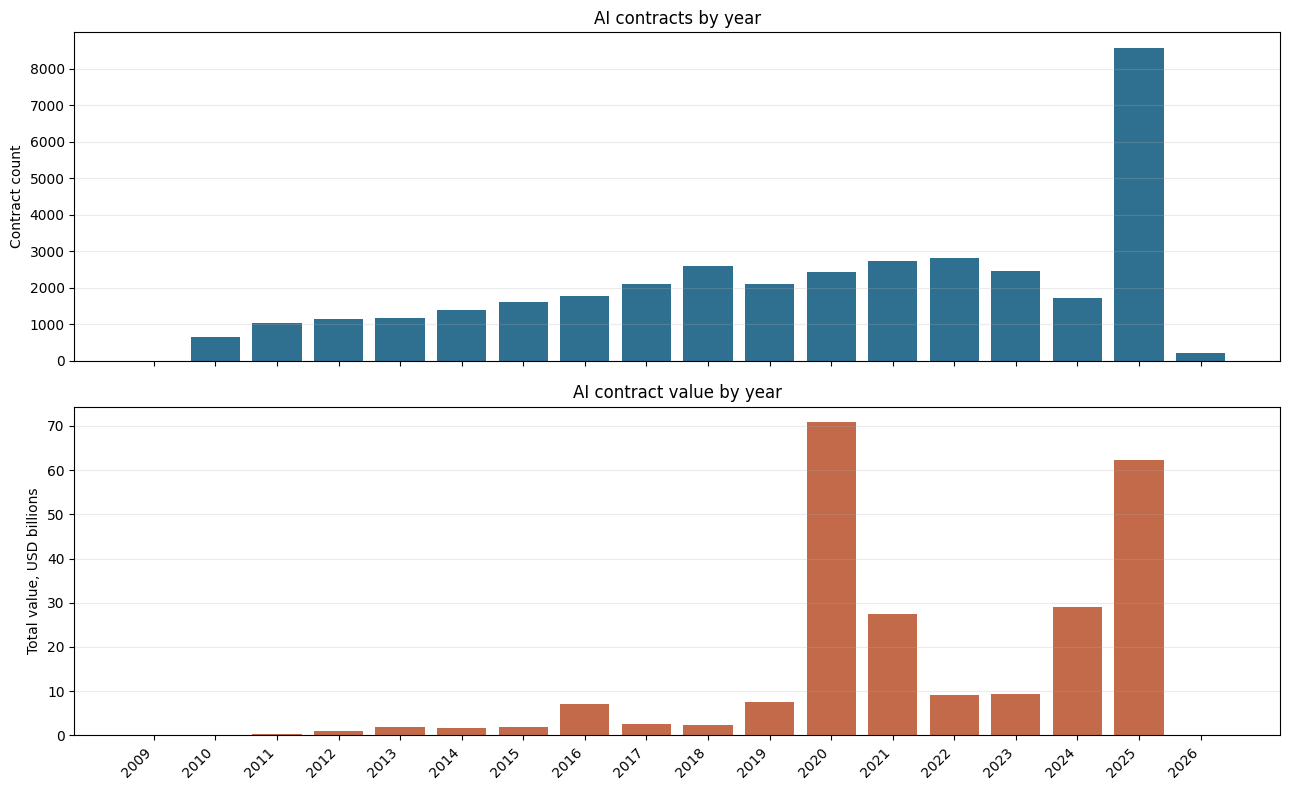

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].bar(annual["year"].astype(str), annual["contracts"], color="#2F6F8F")
axes[0].set_title("AI contracts by year")
axes[0].set_ylabel("Contract count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(annual["year"].astype(str), annual["total_value_usd"] / 1e9, color="#C26A4A")
axes[1].set_title("AI contract value by year")
axes[1].set_ylabel("Total value, USD billions")
axes[1].grid(axis="y", alpha=0.25)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
top_countries = (
    df[df["analysis_country"] != "Unknown"]
    .groupby("analysis_country")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

country_year = (
    df[df["analysis_country"].isin(top_countries)]
    .dropna(subset=["year"])
    .groupby(["year", "analysis_country"], as_index=False)
    .agg(
        contracts=("analysis_country", "size"),
        total_value_usd=("contract_value_usd", "sum"),
    )
)

print(top_countries)
country_year.head()

['US', 'KR', 'CN', 'GB', 'CO']


,year,analysis_country,contracts,total_value_usd
0,2009,GB,1,"93,750.00"
1,2010,GB,7,"5,329,002.21"
2,2010,KR,185,"2,499,788.97"
3,2010,US,412,"100,223,997.84"
4,2011,GB,7,"3,734,564.47"


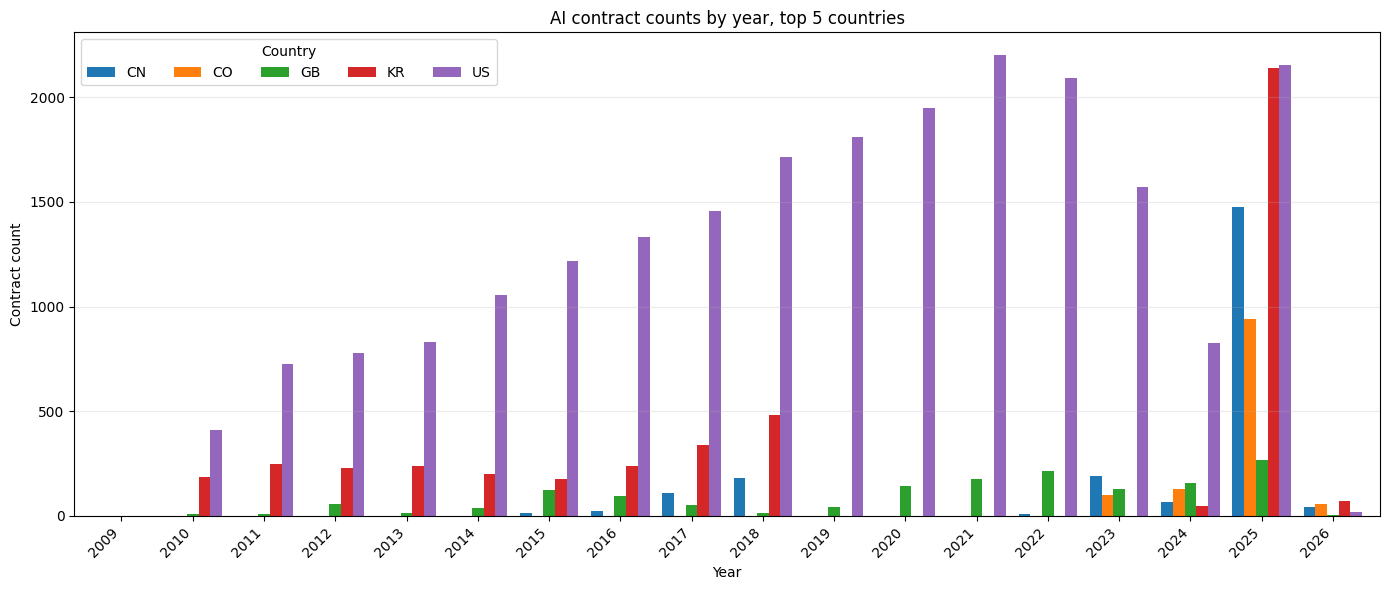

In [10]:
count_pivot = country_year.pivot(index="year", columns="analysis_country", values="contracts").fillna(0)

ax = count_pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_title("AI contract counts by year, top 5 countries")
ax.set_xlabel("Year")
ax.set_ylabel("Contract count")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Country", ncols=min(5, len(top_countries)))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

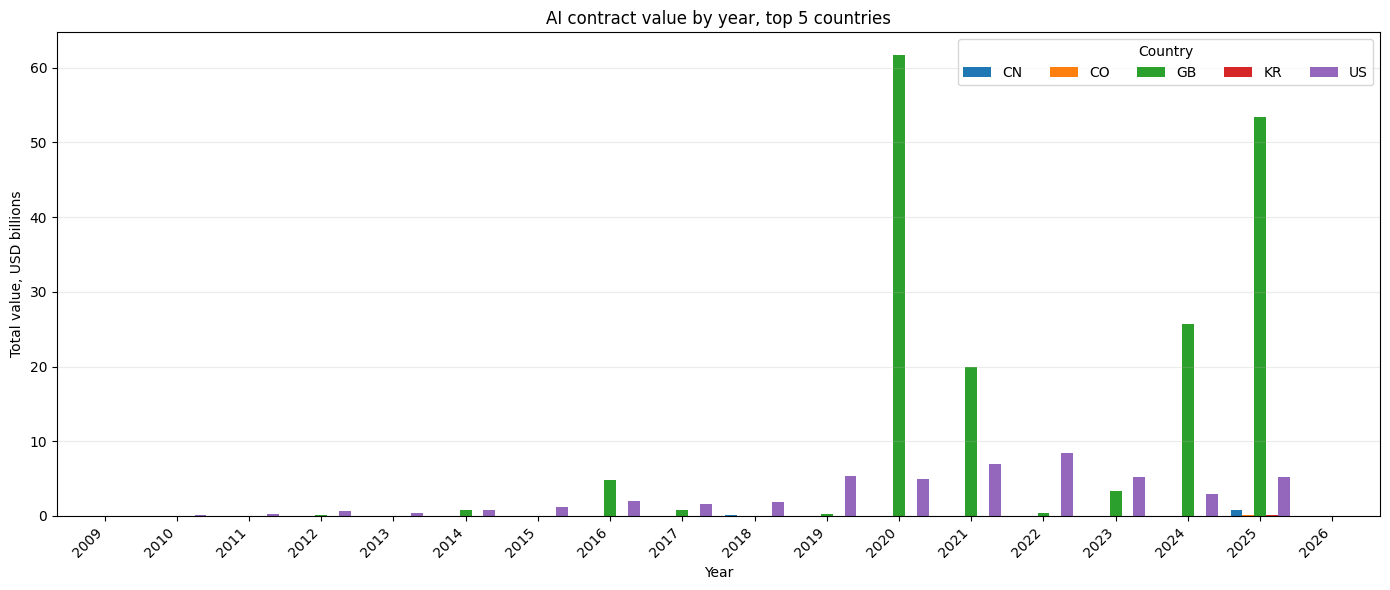

In [11]:
value_pivot = country_year.pivot(index="year", columns="analysis_country", values="total_value_usd").fillna(0) / 1e9

ax = value_pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_title("AI contract value by year, top 5 countries")
ax.set_xlabel("Year")
ax.set_ylabel("Total value, USD billions")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Country", ncols=min(5, len(top_countries)))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
country_summary = (
    df.groupby("analysis_country", as_index=False)
    .agg(
        contracts=("analysis_country", "size"),
        total_value_usd=("contract_value_usd", "sum"),
        median_value_usd=("contract_value_usd", lambda s: s[s > 0].median()),
    )
    .sort_values(["contracts", "total_value_usd"], ascending=False)
)

country_summary.head(20)

,analysis_country,contracts,total_value_usd,median_value_usd
63,US,22152,"47,878,300,992.51","201,871.00"
34,KR,4597,"240,683,730.36","8,462.36"
10,CN,2113,"1,020,173,709.22","206,468.97"
21,GB,1531,"171,280,479,009.28","777,317.26"
11,CO,1226,"105,058,738.09","12,978.06"
53,RU,754,"128,567,989.47","22,379.62"
2,AU,489,"178,254,722.06","75,660.00"
14,DE,428,"1,730,078,021.68","361,159.91"
20,FR,304,"964,023,602.61","600,545.55"
61,UA,297,"13,006,718.71","2,729.64"


## AI term word clouds

The next cells use `AI_MATCH_TERMS` to show which AI-related terms drove the matches overall and for selected countries. If the `wordcloud` package is available, the charts are true word clouds; otherwise the notebook falls back to a matplotlib text cloud.

In [13]:
import math
import random
import re
from collections import Counter

try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

COUNTRY_LABELS = {
    "US": "United States",
    "CN": "China",
    "IN": "India",
    "GB": "United Kingdom",
    "KR": "South Korea",
}

TERM_REPLACEMENTS = {
    "ai": "AI",
    "a i": "AI",
    "llm": "LLM",
    "nlp": "NLP",
    "rpa": "RPA",
    "genai": "GenAI",
}

def clean_ai_term(term):
    term = str(term).split(":", 1)[-1]
    term = term.replace("\\b", " ").replace("\\w*", " ")
    term = term.replace("\\.", ".").replace("[ -]?", " ")
    term = re.sub(r"[^0-9A-Za-z]+", " ", term).strip().lower()
    term = re.sub(r"\s+", " ", term)
    return TERM_REPLACEMENTS.get(term, term.title())

def parse_ai_match_terms(value):
    if pd.isna(value) or not str(value).strip():
        return []
    terms = [clean_ai_term(part) for part in str(value).split(";")]
    return [term for term in terms if term and len(term) > 1]

def term_counter(frame):
    counter = Counter()
    for value in frame.get("AI_MATCH_TERMS", pd.Series(dtype="object")).dropna():
        counter.update(parse_ai_match_terms(value))
    return counter

def plot_word_cloud_from_frequencies(freq, title, ax=None, max_words=80):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(title)
    ax.axis("off")

    freq = Counter({k: v for k, v in freq.items() if v > 0})
    if not freq:
        ax.text(0.5, 0.5, "No matched terms", ha="center", va="center", fontsize=14)
        return ax

    if WordCloud is not None:
        wc = WordCloud(
            width=1200,
            height=650,
            background_color="white",
            colormap="tab20c",
            max_words=max_words,
            random_state=42,
            collocations=False,
        ).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation="bilinear")
        return ax

    rng = random.Random(42)
    top_terms = freq.most_common(max_words)
    max_count = top_terms[0][1]
    colors = plt.cm.tab20c([i % 20 for i in range(len(top_terms))])
    for i, (term, count) in enumerate(top_terms):
        size = 9 + 34 * math.sqrt(count / max_count)
        x = rng.uniform(0.08, 0.92)
        y = rng.uniform(0.10, 0.90)
        ax.text(x, y, term, fontsize=size, color=colors[i], ha="center", va="center", alpha=0.9, transform=ax.transAxes)
    return ax

overall_ai_terms = term_counter(df)
pd.DataFrame(overall_ai_terms.most_common(30), columns=["term", "count"])

,term,count
0,Artificial Intelligence,8351
1,Machine Learning,3929
2,AI,2471
3,Data Science,2210
4,Algorithm Development,1919
5,Ocr,1899
6,Decision Support System,1369
7,Autonomous System,1336
8,Predictive Model,1299
9,Intelligent System,997


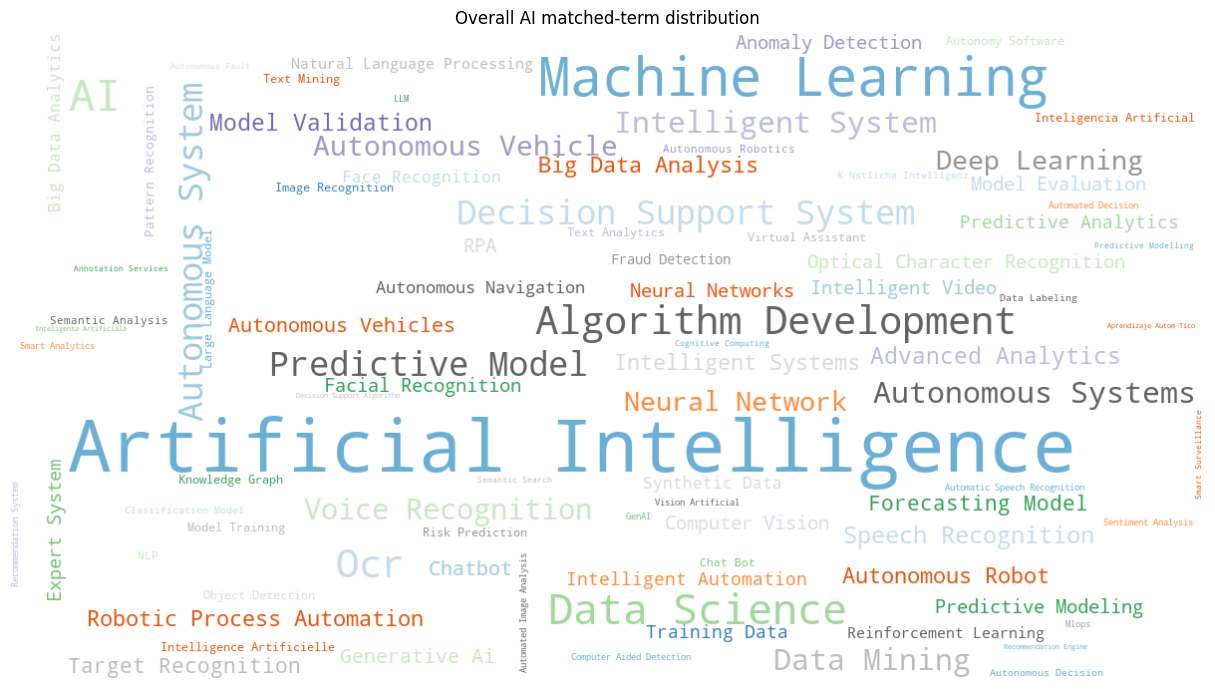

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_word_cloud_from_frequencies(overall_ai_terms, "Overall AI matched-term distribution", ax=ax, max_words=90)
plt.tight_layout()
plt.show()

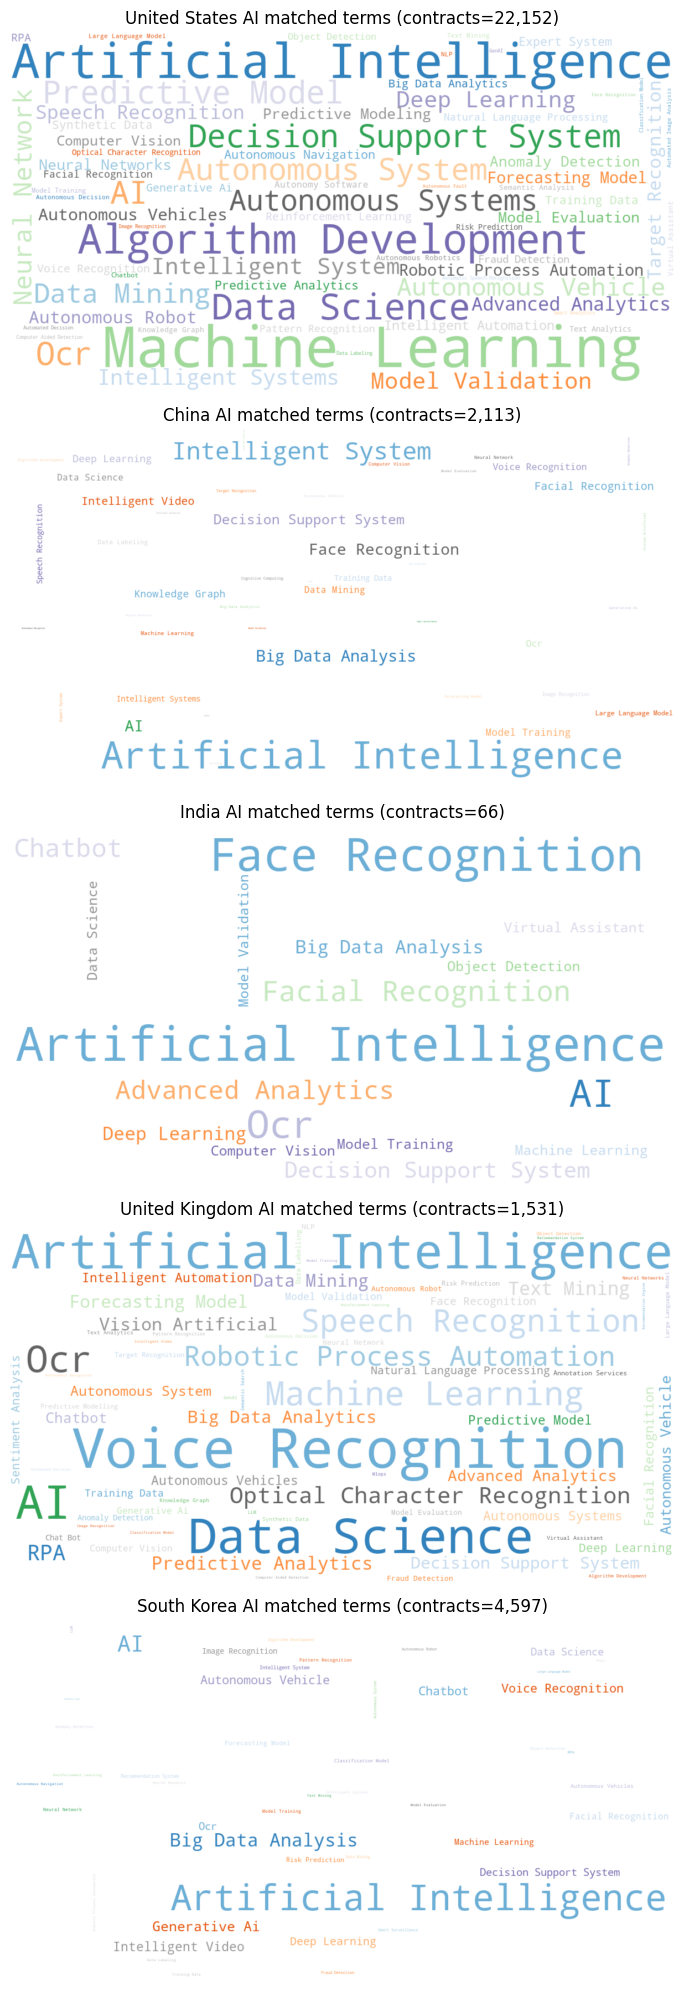

In [15]:
selected_countries = ["US", "CN", "IN", "GB", "KR"]

fig, axes = plt.subplots(len(selected_countries), 1, figsize=(14, 4 * len(selected_countries)))
for ax, country in zip(axes, selected_countries):
    country_frame = df[df["analysis_country"] == country]
    freq = term_counter(country_frame)
    title = f"{COUNTRY_LABELS.get(country, country)} AI matched terms (contracts={len(country_frame):,})"
    plot_word_cloud_from_frequencies(freq, title, ax=ax, max_words=70)

plt.tight_layout()
plt.show()

In [16]:
country_term_tables = []
for country in ["US", "CN", "IN", "GB", "KR"]:
    freq = term_counter(df[df["analysis_country"] == country])
    top = pd.DataFrame(freq.most_common(15), columns=["term", "count"])
    top.insert(0, "country", country)
    country_term_tables.append(top)

country_terms_top = pd.concat(country_term_tables, ignore_index=True)
country_terms_top

,country,term,count
0,US,Machine Learning,3259
1,US,Artificial Intelligence,2743
2,US,Algorithm Development,1896
3,US,Data Science,1444
4,US,Decision Support System,1071
...,...,...,...
70,KR,Ocr,93
71,KR,Decision Support System,92
72,KR,Facial Recognition,63
73,KR,Machine Learning,55


## China rows

In [19]:
china_rows = df[df["analysis_country"] == "CN"].copy()

print(f"China rows: {len(china_rows):,}")

display_cols = [
    "ORIGIN",
    "ORIGIN_ID",
    "TENDER_BIZPORTAL_ID",
    "TRANSACTION_BIZPORTAL_ID",
    "TENDER_DATE_OF_AWARD",
    "TENDER_TITLE",
    "TENDER_DESCRIPTION",
    "AI_MATCH_TERMS",
    "contract_value_usd",
    "RESULT_PARQUET_FILE",
]
display_cols = [col for col in display_cols if col in china_rows.columns]

china_rows[display_cols].head(100)

China rows: 2,113


,ORIGIN,ORIGIN_ID,TENDER_BIZPORTAL_ID,TRANSACTION_BIZPORTAL_ID,TENDER_DATE_OF_AWARD,TENDER_TITLE,TENDER_DESCRIPTION,AI_MATCH_TERMS,contract_value_usd,RESULT_PARQUET_FILE
92,China Procurement,13.00,"190,293,284.00",0.00,2025-01-27,Gaoyou Municipal Health Commission's Artificia...,Gaoyou Municipal Health Commission's Announcem...,core_ai_en: artificial intelligence; core_ai_e...,"340,645.11",ai_contracts_all_files.parquet
99,China Procurement,13.00,"116,604,098.00",0.00,2024-01-19,Clinical auxiliary decision -making support sy...,Artificial Intelligence -based clinical auxili...,core_ai_en: artificial intelligence,"165,563.44",ai_contracts_all_files.parquet
128,China Procurement,13.00,"191,905,589.00",0.00,2025-02-11,Artificial Intelligence Exhibition Hall Exhibi...,Sichuan Science and Technology Museum Artifici...,core_ai_en: artificial intelligence,"136,157.79",ai_contracts_all_files.parquet
209,China Procurement,13.00,"119,863,947.00",0.00,2024-04-08,School bus dynamic information supervision int...,School bus dynamic information supervision int...,broad_ai_en: intelligent video,"383,709.51",ai_contracts_all_files.parquet
262,China Procurement,13.00,"202,303,048.00",0.00,2025-08-08,General Factor Method-Artificial Intelligence-...,General Factor Method - Artificial Intelligenc...,core_ai_en: artificial intelligence,"483,714.84",ai_contracts_all_files.parquet
...,...,...,...,...,...,...,...,...,...,...
2163,China Procurement,13.00,"199,861,974.00",0.00,2025-07-10,The first batch of AI course construction serv...,Jianghan University's first batch of AI course...,core_ai_en: \bAI\b; broad_ai_en: knowledge graph,"166,195.27",ai_contracts_all_files.parquet
2164,China Procurement,13.00,"200,544,099.00",0.00,2025-07-17,Guangdong Medical University Medical Artificia...,Guangdong Medical University Medical Artificia...,core_ai_en: artificial intelligence,"1,371,160.39",ai_contracts_all_files.parquet
2175,China Procurement,13.00,"204,164,654.00",0.00,2025-09-16,Procurement of electronic instruments and equi...,Chongqing Technology and Business University S...,core_ai_en: artificial intelligence,"980,567.59",ai_contracts_all_files.parquet
2179,China Procurement,13.00,"205,356,637.00",0.00,2025-10-14,Intelligent Speech Recognition Project of Binz...,Announcement of the Winning Bid (Transaction) ...,core_ai_en: speech recognition,"68,636.95",ai_contracts_all_files.parquet
